In [22]:

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pathlib import Path
from scipy import stats

TASK_ROOT = Path.cwd().parent
INPUT = TASK_ROOT / "input"
OUTPUT = TASK_ROOT / "output"
FIGURES = OUTPUT / "figures"
RESULTS = OUTPUT / "results"
FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

EPS = 0.49
Y = 20
PAPER_BG = "#f3f0e9"
INK = "#263238"
EMP_COLOR = "#303030"
MODEL_ORDER = ["arw4", "unfitted_grw", "grw_y", "grw_global", "ar1_y", "ar1_s", "ar1_s_globalinit", "hurdle_ar1_s", "hurdle_ar1_s_p", "hurdle_ar3_s_p"]
MODEL_NAMES = {"arw4": "ARW4", "unfitted_grw": "Unfitted-GRW", "grw_y": "GRW-Y", "grw_global": "GRW-G", "ar1_y": "AR(1)-GRW-Y", "ar1_s": "AR(1)-GRW-S", "ar1_s_globalinit": "AR(1)-GRW-S-G", "hurdle_ar1_s": "Hurdle-AR(1)-GRW-S", "hurdle_ar1_s_p": "Hurdle-AR(1)-GRW-S-P", "hurdle_ar3_s_p": "Hurdle-AR(3)-GRW-S-P"}
MODEL_COLORS = {"arw4": "#0072B2", "unfitted_grw": "#D55E00", "grw_y": "#E69F00", "grw_global": "#8C564B", "ar1_y": "#009E73", "ar1_s": "#56B4E9", "ar1_s_globalinit": "#17BECF", "hurdle_ar1_s": "#CC79A7", "hurdle_ar1_s_p": "#6A3D9A", "hurdle_ar3_s_p": "#000000"}
STAGE_ORDER = ["0", "1-4", "5-7", "8-20"]
STAGE_SPANS = [("0", 0, 0), ("1-4", 1, 4), ("5-7", 5, 7), ("8-20", 8, 19)]
STAGE_BOUNDS = [0.5, 4.5, 7.5]


def resolve_root(name, marker):
    for candidate in [INPUT / name, INPUT]:
        if (candidate / marker).is_file():
            return candidate

def style_axis(ax, stages=False):
    ax.set_facecolor(PAPER_BG)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(colors=INK)
    ax.xaxis.label.set_color(INK)
    ax.yaxis.label.set_color(INK)
    ax.title.set_color(INK)
    if stages:
        for boundary in STAGE_BOUNDS:
            ax.axvline(boundary, color="#9aa0a4", lw=0.8, ls=":", zorder=0)

def savefig(fig, filename):
    fig.savefig(FIGURES / filename, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())

mpl.rcParams.update({"figure.facecolor": PAPER_BG, "axes.facecolor": PAPER_BG, "savefig.facecolor": PAPER_BG, "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 11, "legend.fontsize": 8})
sns.set_theme(style="white", rc={"axes.facecolor": PAPER_BG, "figure.facecolor": PAPER_BG})
PREPARE = resolve_root("prepare", "df_traj_all.csv")
SIMULATE = resolve_root("simulate", "simulation-registry.csv")

In [23]:
emp = pd.read_csv(PREPARE / "df_traj_all.csv")
emp["CareerAge"] = emp["CareerAgeZero"].astype(int)
emp = emp.sort_values(["dblp_id", "CareerAge"]).copy()
grouped = emp.groupby("dblp_id", sort=False)
emp["pubs_adj_next_model"] = grouped["pubs_adj"].shift(-1)
emp["CareerAge_next_model"] = grouped["CareerAge"].shift(-1)
emp["log_pubs_adj"] = np.log(emp["pubs_adj"] + EPS)
emp["log_pubs_next"] = grouped["log_pubs_adj"].shift(-1)
emp["q_adj_delta"] = emp["pubs_adj_next_model"] - emp["pubs_adj"]
emp["log_delta"] = emp["log_pubs_next"] - emp["log_pubs_adj"]
emp["state"] = emp["pubs_adj"].gt(0).astype(int)
emp["next_state"] = emp["pubs_adj_next_model"].gt(0).astype(int)
is_next_year = emp["CareerAge_next_model"].eq(emp["CareerAge"] + 1)
emp_fit = emp.loc[is_next_year & emp["CareerAge"].between(0, Y - 1)].copy()

full_group = emp.groupby("dblp_id")["CareerAge"]
full_mask = full_group.transform("size").eq(Y + 1) & full_group.transform("min").eq(0) & full_group.transform("max").eq(Y)
emp_full_frame = emp.loc[full_mask].copy()
emp_panel_df = emp_full_frame.pivot(index="CareerAge", columns="dblp_id", values="pubs_adj").reindex(np.arange(Y + 1))
emp_panel = emp_panel_df.to_numpy(dtype=float)

simulation_registry = pd.read_csv(SIMULATE / "simulation-registry.csv")
available_models = [tag for tag in MODEL_ORDER if (SIMULATE / tag / "trajectories.npy").is_file()]
trajs = {tag: np.load(SIMULATE / tag / "trajectories.npy", mmap_mode="r", allow_pickle=False) for tag in available_models}

In [24]:
def empirical_last_four():
    path = PREPARE / "df_rolling_pubs_cs.csv"
    if path.is_file():
        rolling = pd.read_csv(path)
    else:
        person = "dblp" if "dblp" in emp.columns else "dblp_id"
        ordered = emp.sort_values([person, "CareerAge"])
        rolling4 = ordered.groupby(person)["pubs_adj"].rolling(4, min_periods=4).sum().reset_index(level=0, drop=True)
        rolling = ordered.assign(RollingPubs=rolling4).dropna(subset=["RollingPubs"]).groupby(person, as_index=False).agg(FourYearProd=("RollingPubs", "last"), TotalYears=("CareerAge", "max"))
    rolling = rolling.loc[rolling["TotalYears"].gt(4) & rolling["FourYearProd"].gt(0)].copy()
    return rolling["FourYearProd"].to_numpy(dtype=float), rolling

def optional_aarc_last_four():
    for path in [PREPARE / "df_rolling_pubs.csv", PREPARE / "df_rolling_pubs_all_fields.csv"]:
        if path.is_file():
            frame = pd.read_csv(path)
            if {"Field", "FourYearProd"}.issubset(frame.columns):
                return {field: group.loc[group["FourYearProd"].gt(0), "FourYearProd"].to_numpy(dtype=float) for field, group in frame.groupby("Field")}
    return {}

cs_last_four, cs_rolling = empirical_last_four()
aarc_last_four = optional_aarc_last_four()

In [25]:
def qq_details(productivity):
    productivity = np.asarray(productivity, dtype=float)
    productivity = productivity[np.isfinite(productivity) & (productivity > 0)]
    logged = np.log2(productivity)
    mu, sigma = logged.mean(), logged.std(ddof=1)
    standardized = (logged - mu) / sigma
    (theoretical, ordered), (_, _, corr) = stats.probplot(standardized, dist="norm", fit=True, rvalue=True)
    return {"theoretical": theoretical, "ordered": ordered, "corr": float(corr), "n": len(logged), "log_mean": mu, "log_sd": sigma}

def plot_qq(ax, values, label, color, lw=2, ls="-", alpha=1):
    details = qq_details(values)
    ax.plot(details["theoretical"], details["ordered"], color=color, lw=lw, ls=ls, alpha=alpha, label=label)
    return details

EMP_WINDOWS = {"Last four observed / 17-20": cs_last_four, "Full career, 0-20": emp_panel.sum(axis=0), "Stage 0": emp_panel[0], "Stage 1-4": emp_panel[1:5].sum(axis=0), "Stage 5-7": emp_panel[5:8].sum(axis=0), "Stage 8-20": emp_panel[8:21].sum(axis=0)}
WINDOW_ORDER = list(EMP_WINDOWS)

def simulation_windows(values):
    return {"Last four observed / 17-20": np.asarray(values[17:21].sum(axis=0)), "Full career, 0-20": np.asarray(values.sum(axis=0)), "Stage 0": np.asarray(values[0]), "Stage 1-4": np.asarray(values[1:5].sum(axis=0)), "Stage 5-7": np.asarray(values[5:8].sum(axis=0)), "Stage 8-20": np.asarray(values[8:21].sum(axis=0))}

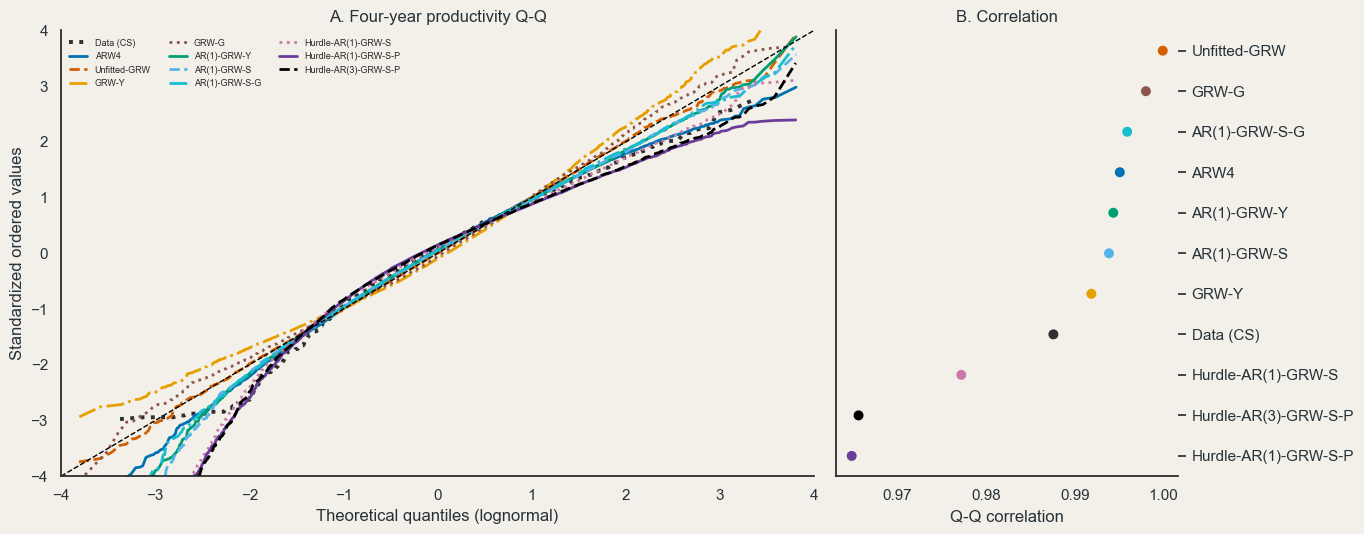

In [26]:
n_entries = len(aarc_last_four) + 1 + len(available_models)
fig, axes = plt.subplots(1, 2, figsize=(13.8, max(5.5, 0.32 * n_entries)), gridspec_kw={"width_ratios": [2.2, 1]})
fig.patch.set_facecolor(PAPER_BG)
style_axis(axes[0])
rows = []
for field, values in aarc_last_four.items():
    details = plot_qq(axes[0], values, field, "#9ACD32", lw=0.9, alpha=0.45)
    rows.append({"source": field, "source_type": "empirical field", "model_tag": np.nan, "window": WINDOW_ORDER[0], **{k: details[k] for k in ["corr", "n", "log_mean", "log_sd"]}})
details = plot_qq(axes[0], cs_last_four, "Data (CS)", EMP_COLOR, lw=2.8, ls=":")
rows.append({"source": "Data (CS)", "source_type": "empirical", "model_tag": "empirical", "window": WINDOW_ORDER[0], **{k: details[k] for k in ["corr", "n", "log_mean", "log_sd"]}})
styles = ["-", "--", "-.", ":"]
for i, tag in enumerate(available_models):
    ls = styles[i % len(styles)]
    details = plot_qq(axes[0], np.asarray(trajs[tag][17:21].sum(axis=0)), MODEL_NAMES[tag], MODEL_COLORS[tag], lw=2, ls=ls)
    rows.append({"source": MODEL_NAMES[tag], "source_type": "simulated", "model_tag": tag, "window": WINDOW_ORDER[0], **{k: details[k] for k in ["corr", "n", "log_mean", "log_sd"]}})
axes[0].plot([-4, 4], [-4, 4], color="black", lw=1, ls="--")
axes[0].set(xlim=(-4, 4), ylim=(-4, 4), xlabel="Theoretical quantiles (lognormal)", ylabel="Standardized ordered values", title="A. Four-year productivity Q-Q")
axes[0].legend(frameon=False, ncol=3, fontsize=6.5)

corr = pd.DataFrame(rows).sort_values("corr").reset_index(drop=True)
style_axis(axes[1])
colors = [MODEL_COLORS.get(tag, EMP_COLOR if source == "Data (CS)" else "#9ACD32") for tag, source in zip(corr["model_tag"], corr["source"])]
axes[1].scatter(corr["corr"], np.arange(len(corr)), c=colors, s=38)
axes[1].set_yticks(np.arange(len(corr)), corr["source"])
axes[1].yaxis.tick_right()
axes[1].set_xlabel("Q-Q correlation")
axes[1].set_title("B. Correlation")
fig.tight_layout()
savefig(fig, "qq_last_four_all_models.png")
plt.show()

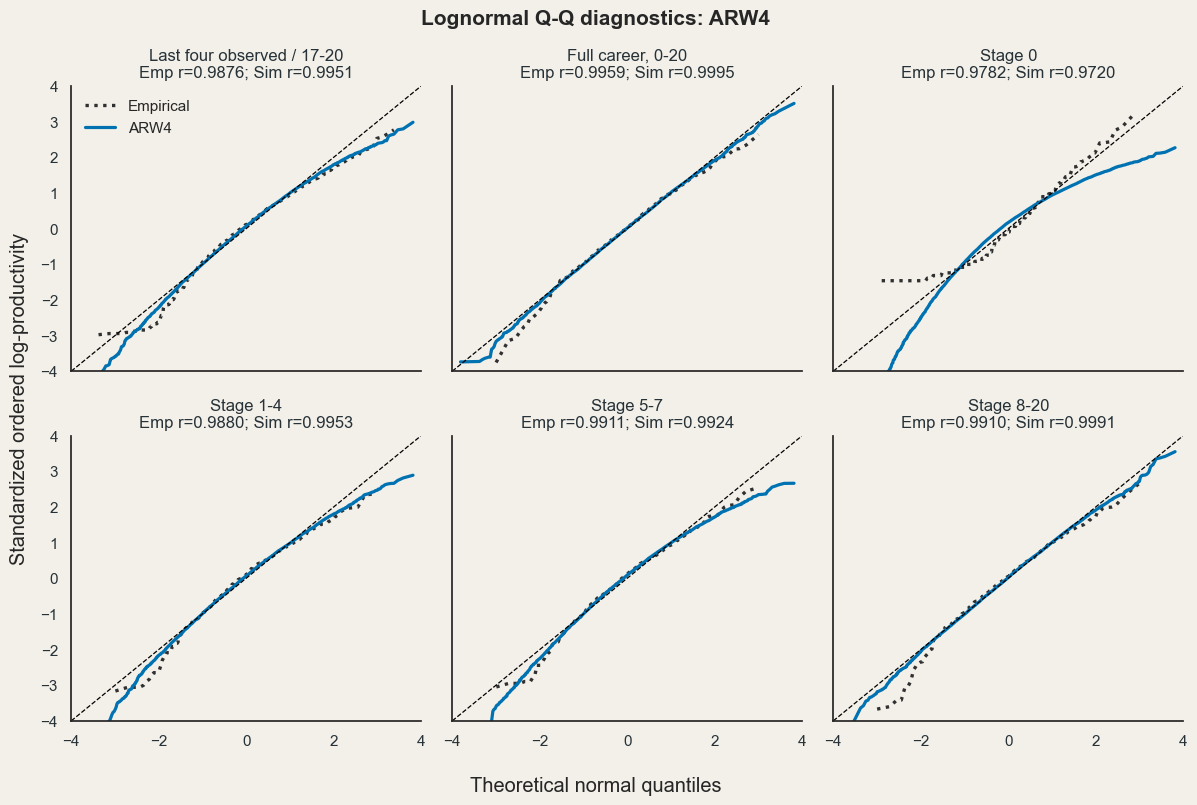

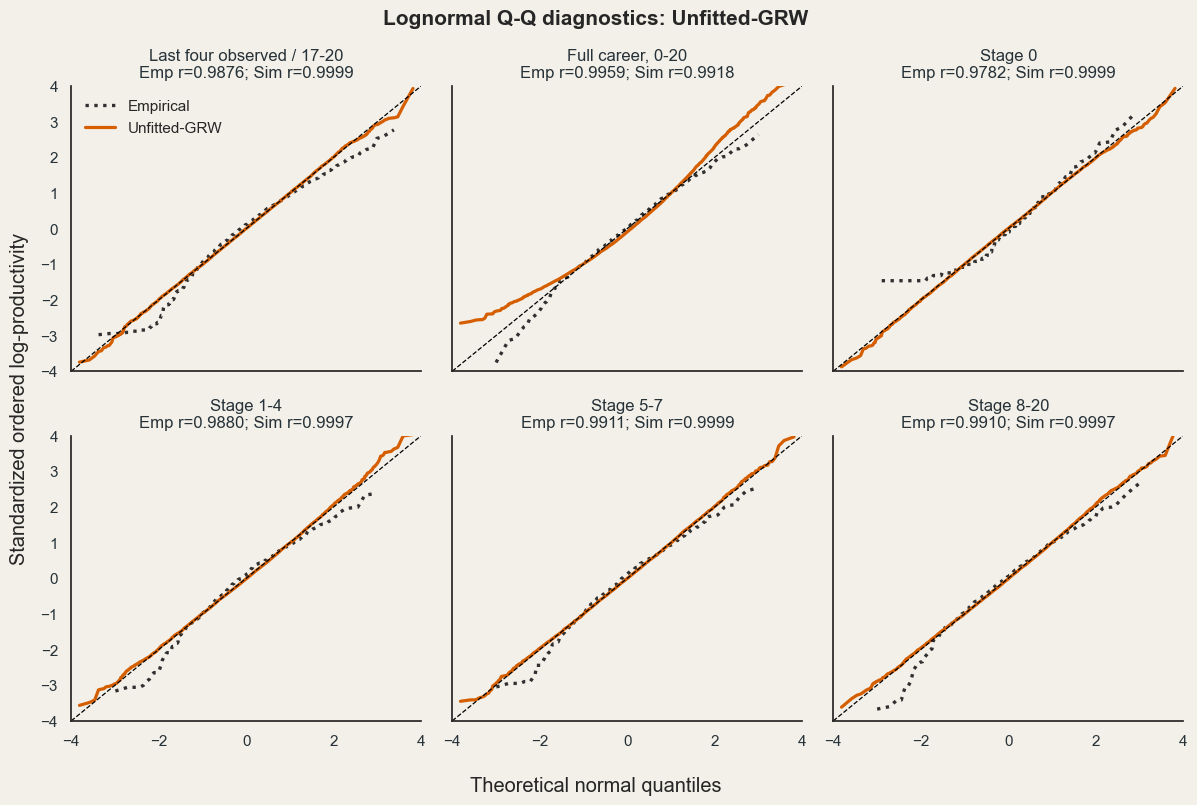

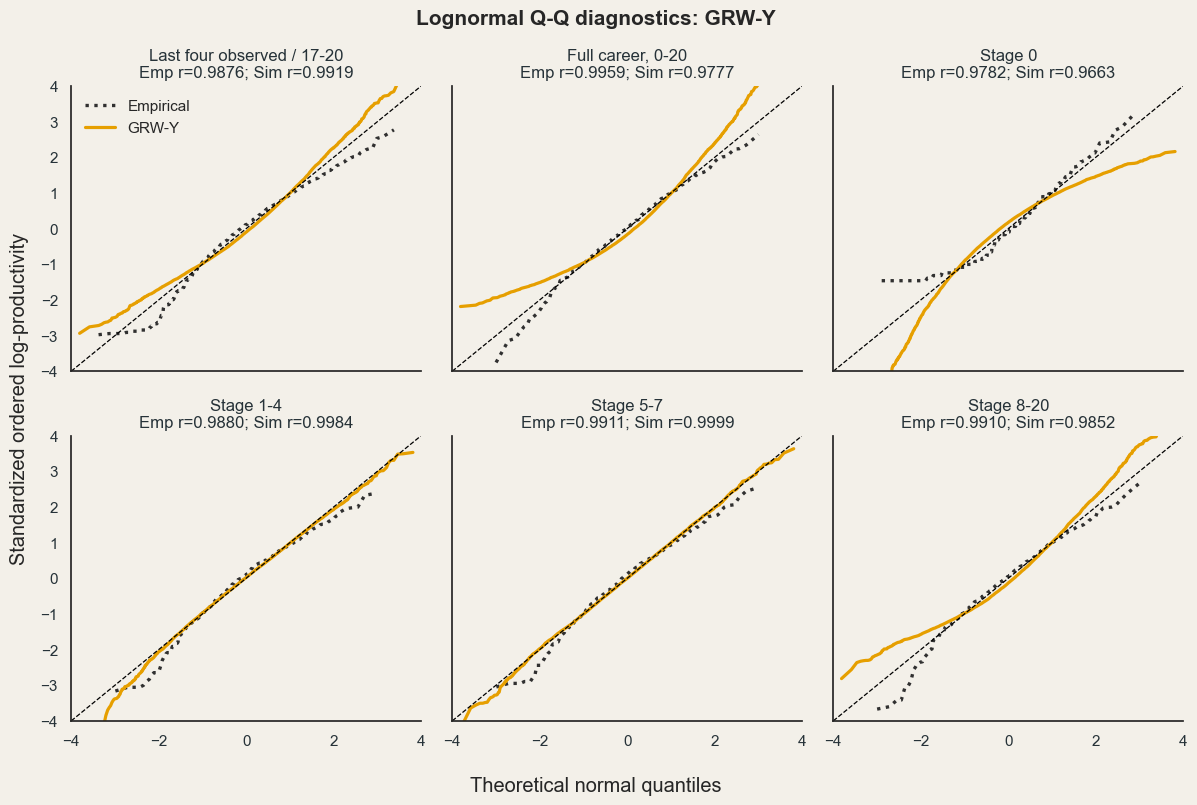

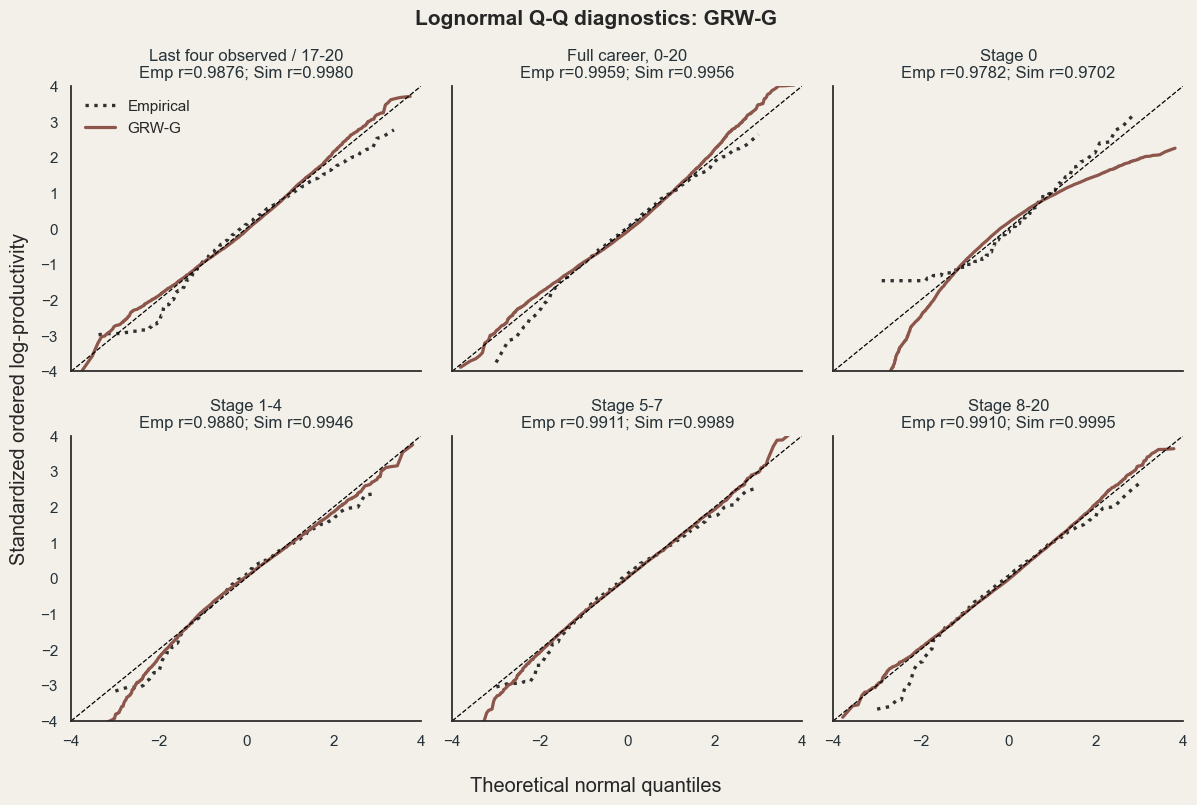

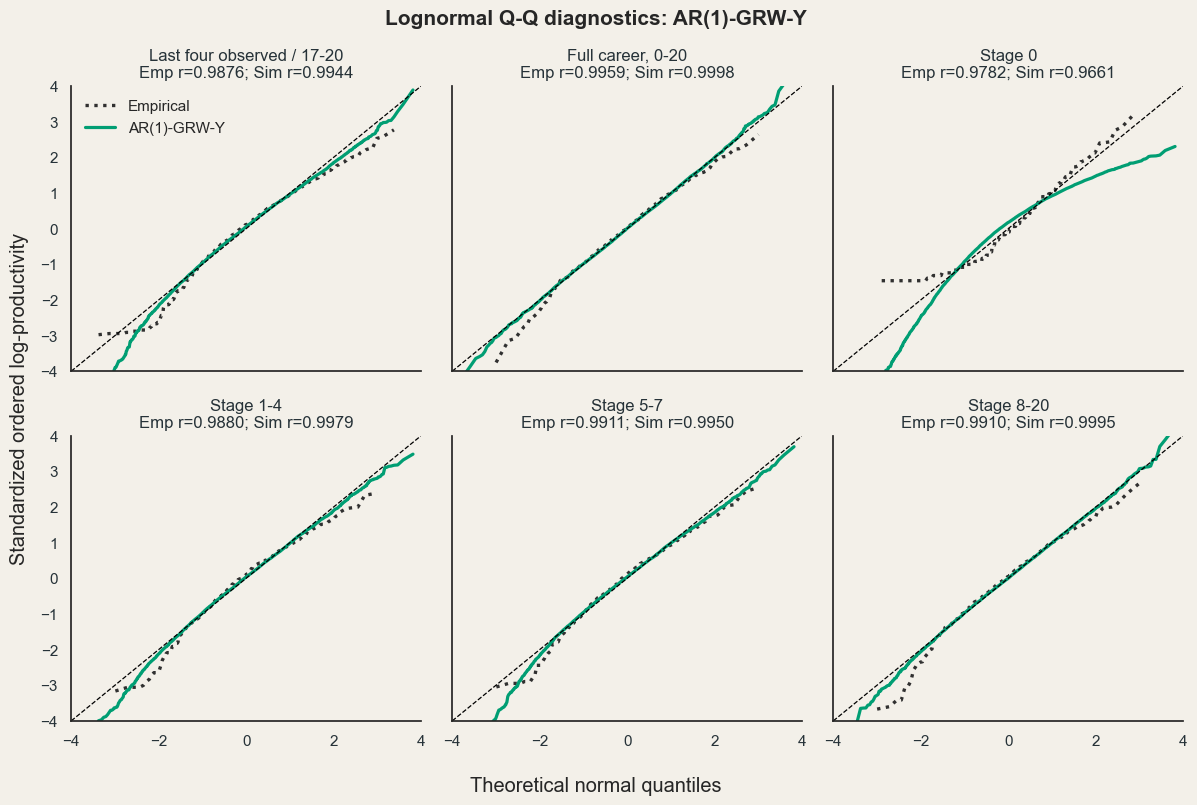

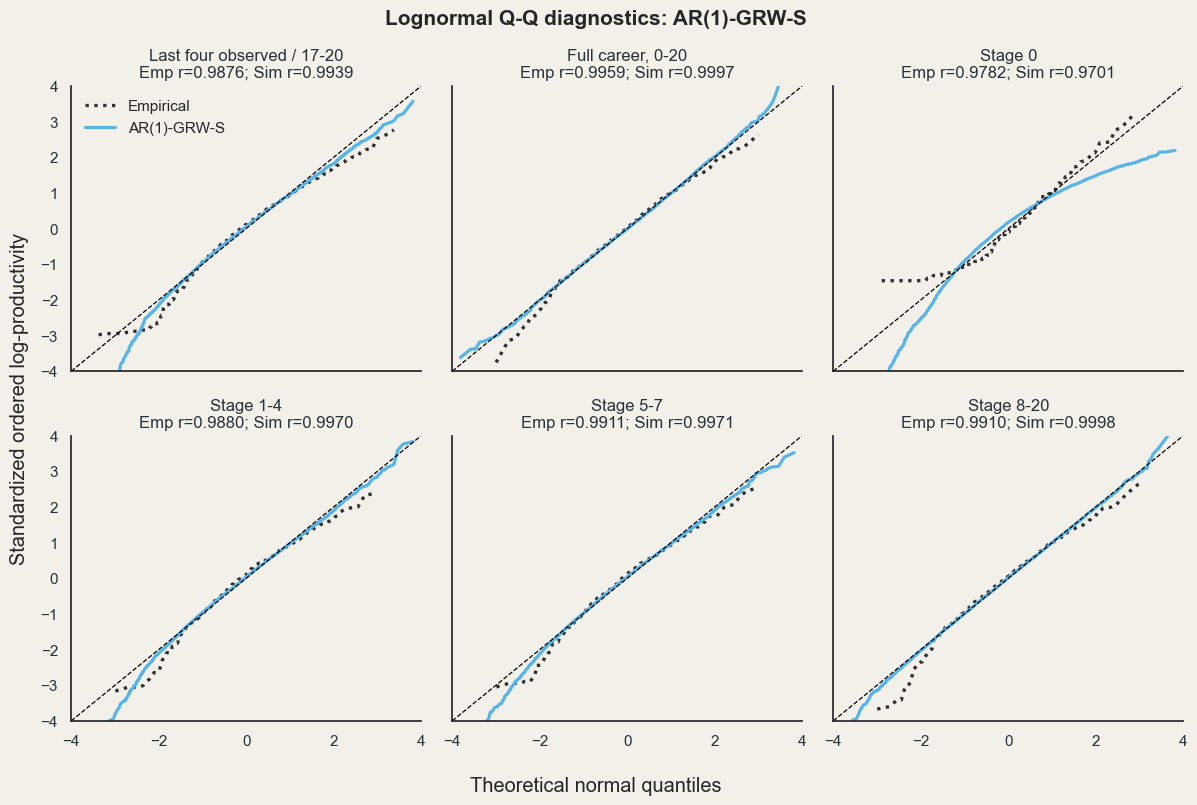

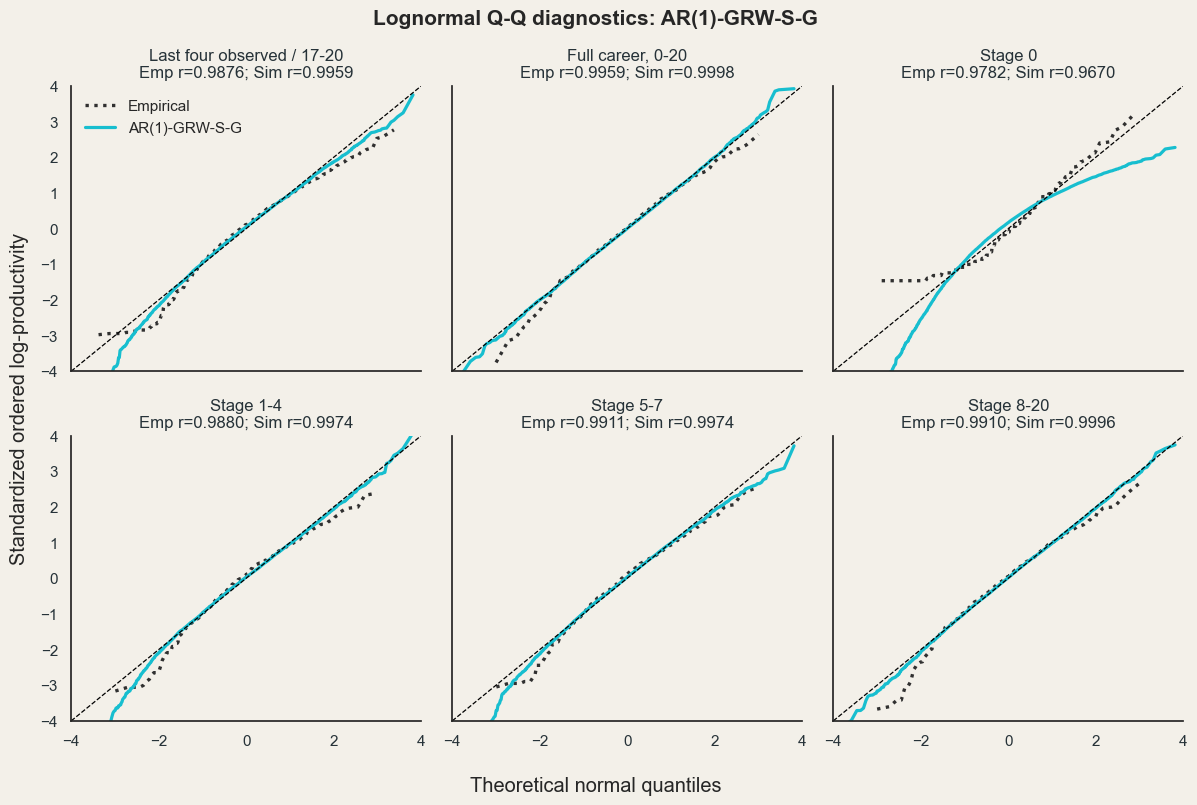

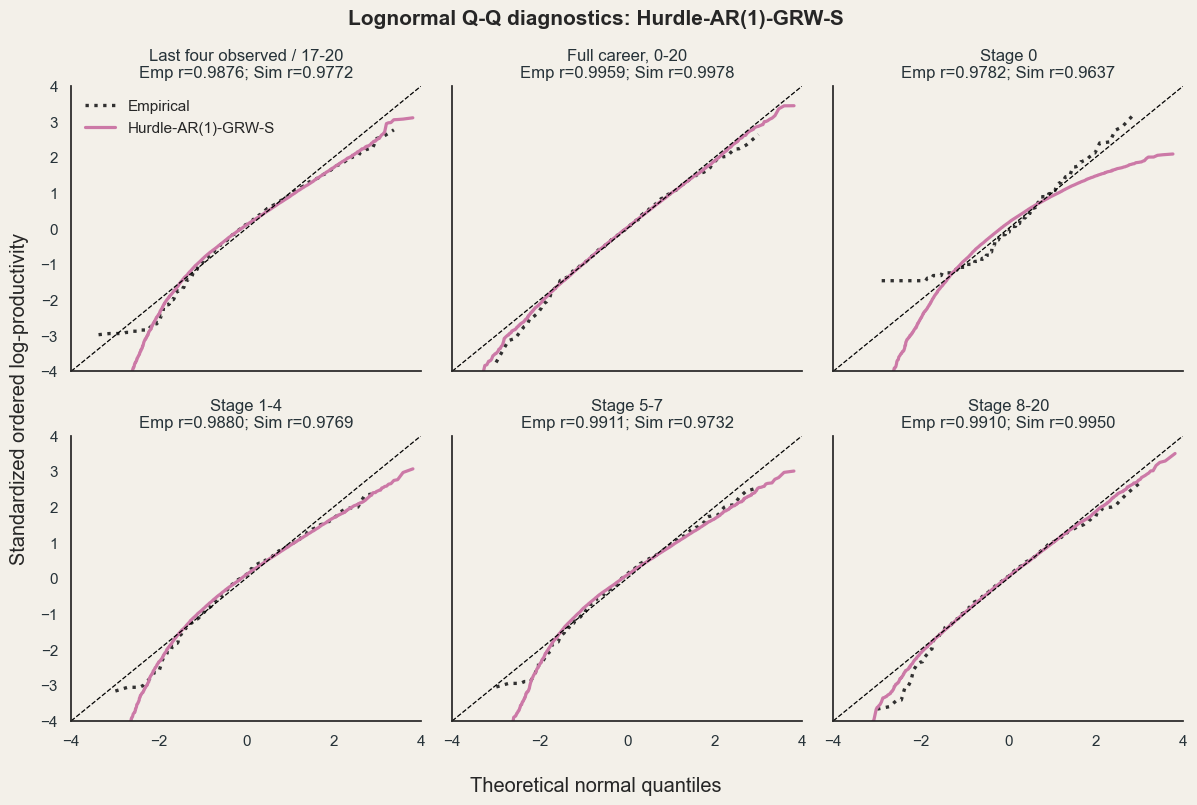

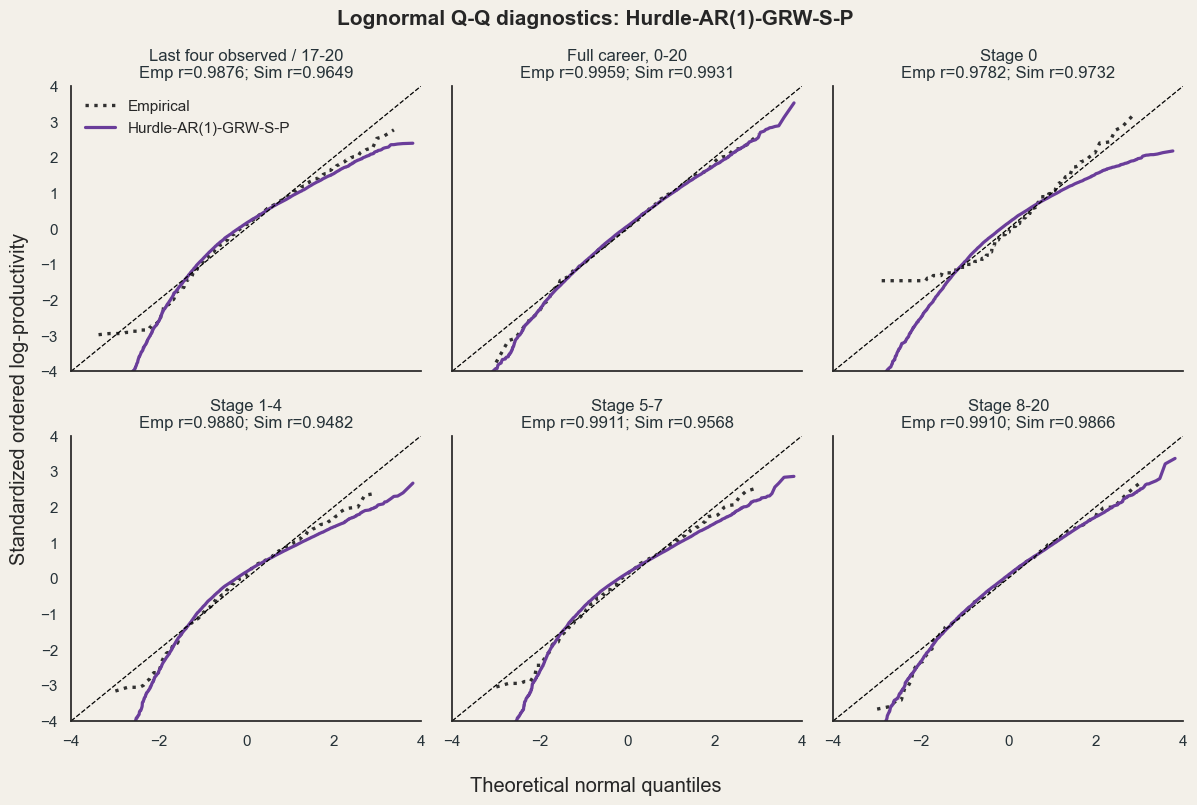

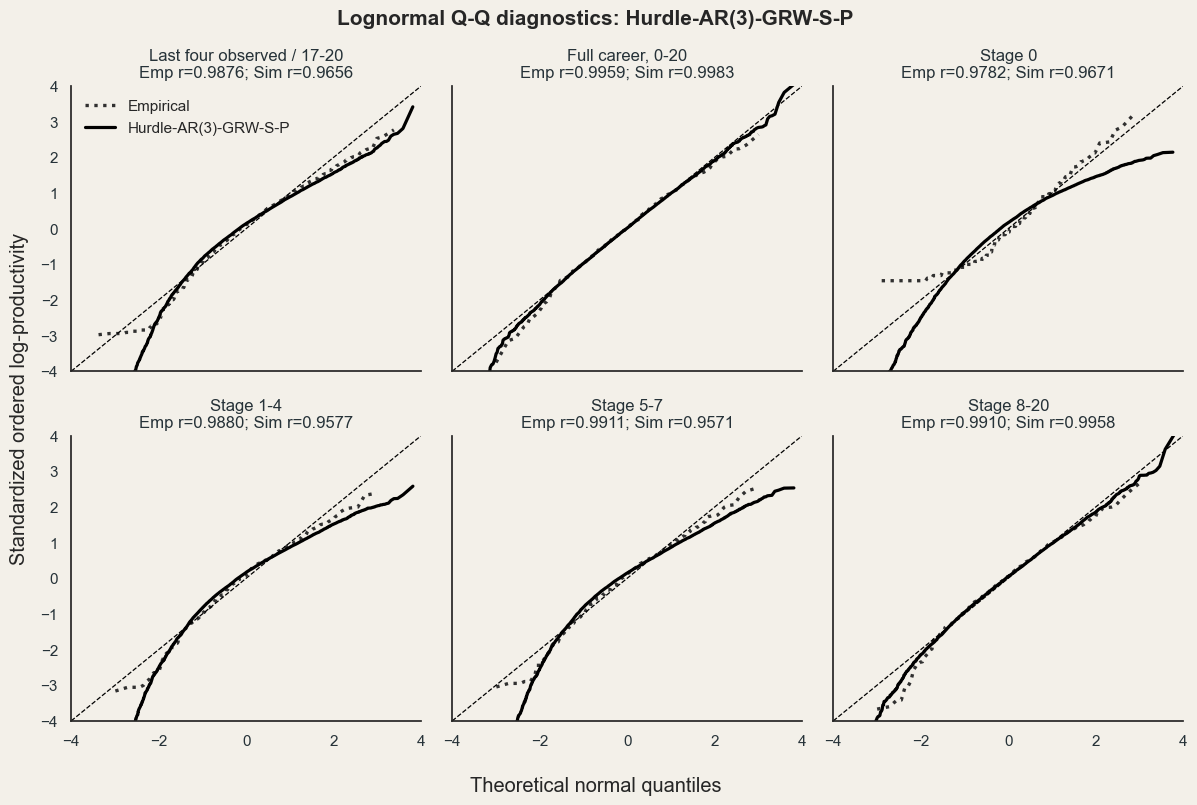

,source,source_type,model_tag,window,corr,n,log_mean,log_sd
13,Data (CS),empirical,arw4,"Full career, 0-20",0.995945,510,6.927063,1.014833
25,Data (CS),empirical,unfitted_grw,"Full career, 0-20",0.995945,510,6.927063,1.014833
37,Data (CS),empirical,grw_y,"Full career, 0-20",0.995945,510,6.927063,1.014833
49,Data (CS),empirical,grw_global,"Full career, 0-20",0.995945,510,6.927063,1.014833
61,Data (CS),empirical,ar1_y,"Full career, 0-20",0.995945,510,6.927063,1.014833
...,...,...,...,...,...,...,...,...
46,GRW-Y,simulated,grw_y,Stage 8-20,0.985180,10000,7.837021,4.097852
106,Hurdle-AR(1)-GRW-S,simulated,hurdle_ar1_s,Stage 8-20,0.994982,9999,6.051527,0.814174
118,Hurdle-AR(1)-GRW-S-P,simulated,hurdle_ar1_s_p,Stage 8-20,0.986602,10000,6.094477,0.933101
130,Hurdle-AR(3)-GRW-S-P,simulated,hurdle_ar3_s_p,Stage 8-20,0.995812,10000,5.984052,1.064095


In [27]:
all_rows = rows.copy()
for tag in available_models:
    sim = simulation_windows(trajs[tag])
    fig, axes = plt.subplots(2, 3, figsize=(12.2, 8.1), sharex=True, sharey=True)
    fig.patch.set_facecolor(PAPER_BG)
    for ax, window in zip(axes.flat, WINDOW_ORDER):
        style_axis(ax)
        empirical = plot_qq(ax, EMP_WINDOWS[window], "Empirical", EMP_COLOR, lw=2.4, ls=":")
        simulated = plot_qq(ax, sim[window], MODEL_NAMES[tag], MODEL_COLORS[tag], lw=2.3)
        ax.plot([-4, 4], [-4, 4], color="black", lw=0.9, ls="--")
        ax.set(xlim=(-4, 4), ylim=(-4, 4), title=f"{window}\nEmp r={empirical['corr']:.4f}; Sim r={simulated['corr']:.4f}")
        all_rows += [
            {"source": "Data (CS)", "source_type": "empirical", "model_tag": tag, "window": window, **{k: empirical[k] for k in ["corr", "n", "log_mean", "log_sd"]}},
            {"source": MODEL_NAMES[tag], "source_type": "simulated", "model_tag": tag, "window": window, **{k: simulated[k] for k in ["corr", "n", "log_mean", "log_sd"]}}
        ]
    axes[0, 0].legend(frameon=False)
    fig.supxlabel("Theoretical normal quantiles")
    fig.supylabel("Standardized ordered log-productivity")
    fig.suptitle(f"Lognormal Q-Q diagnostics: {MODEL_NAMES[tag]}", fontsize=15, fontweight="bold")
    fig.tight_layout()
    savefig(fig, f"qq_windows_{tag}.png")
    plt.show()

qq_summary = pd.DataFrame(all_rows).drop_duplicates(subset=["source", "source_type", "model_tag", "window"], keep="last")
qq_summary.to_csv(RESULTS / "qq-correlations.csv", index=False)
display(qq_summary.sort_values(["window", "source_type", "source"]))

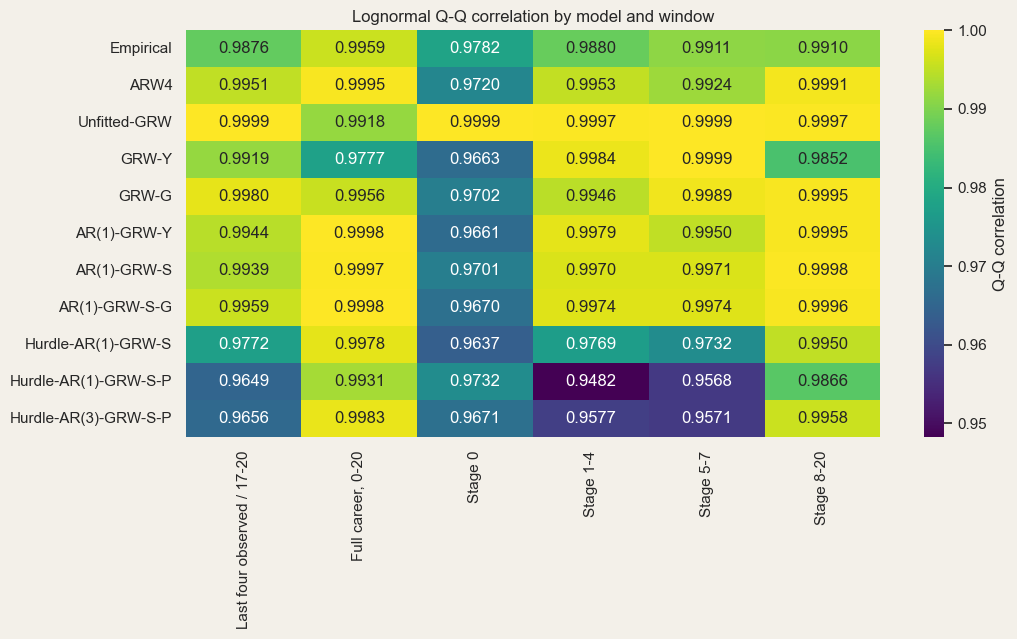

In [28]:
sim_summary = qq_summary.loc[qq_summary["source_type"].eq("simulated")].pivot(index="source", columns="window", values="corr").reindex([MODEL_NAMES[tag] for tag in available_models])
emp_summary = pd.DataFrame({"Empirical": [qq_details(EMP_WINDOWS[window])["corr"] for window in WINDOW_ORDER]}, index=WINDOW_ORDER).T
heatmap_data = pd.concat([emp_summary, sim_summary]).reindex(columns=WINDOW_ORDER)
fig, ax = plt.subplots(figsize=(10.8, max(5.2, 0.45 * len(heatmap_data) + 1.6)))
fig.patch.set_facecolor(PAPER_BG)
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="viridis", vmin=heatmap_data.min().min(), vmax=1, ax=ax, cbar_kws={"label": "Q-Q correlation"})
ax.set(xlabel="", ylabel="", title="Lognormal Q-Q correlation by model and window")
fig.tight_layout()
savefig(fig, "qq_correlation_all_windows.png")
plt.show()